# Customer Churn Prediction with Neural Networks

**Context:** Graduate predictive analytics project, Northeastern University
**Business case:** ConnectTel (telecom, ~5,000 customers, ~28% churn)



In [1]:
#Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

#Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = {"No": "#4C9F9F", "Yes": "#E76F51"}   # non-churn vs churn

#Load the data
DATA_PATH = "telco_churn.csv" if os.path.exists("telco_churn.csv") \
            else r"C:\Users\chery\Downloads\telco_churn.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns from {DATA_PATH}")
df.head()


ModuleNotFoundError: No module named 'sklearn'

## Step 1 - Business Problem

The strategic framing (stakeholder, decision, success criteria) is written up in
the report. The one quantitative item that belongs in code is the **estimated
annual revenue loss from churn**, calculated below.


In [ ]:
#Estimated annual revenue loss from churn
n_customers   = 5000
churn_rate    = 0.28                       # ~28% per the business scenario
acq_cost_low  = 300                        # low end of replacement cost
acq_cost_high = 500                        # high end of replacement cost

annual_churners = n_customers * churn_rate
loss_low  = annual_churners * acq_cost_low
loss_high = annual_churners * acq_cost_high

print(f"Estimated customers lost per year : {annual_churners:,.0f}")
print(f"Replacement cost @ ${acq_cost_low}/customer : ${loss_low:,.0f}")
print(f"Replacement cost @ ${acq_cost_high}/customer: ${loss_high:,.0f}")
print(f"=> Annual churn exposure: ${loss_low:,.0f} to ${loss_high:,.0f}")


Estimated customers lost per year : 1,400
Replacement cost @ $300/customer : $420,000
Replacement cost @ $500/customer: $700,000
=> Annual churn exposure: $420,000 to $700,000


## Step 2 - Data Cleaning & Initial Findings

### 2.1 Inspect the data
Get a first read on size, data types, summary statistics, and missingness.

In [ ]:
# Structure and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           5000 non-null   str    
 1   Gender               5000 non-null   str    
 2   Age                  5000 non-null   int64  
 3   Senior_Citizen       5000 non-null   int64  
 4   Partner              5000 non-null   str    
 5   Dependents           5000 non-null   str    
 6   Tenure_Months        4801 non-null   float64
 7   Phone_Service        5000 non-null   str    
 8   Multiple_Lines       5000 non-null   str    
 9   Internet_Service     5000 non-null   str    
 10  Online_Security      5000 non-null   str    
 11  Online_Backup        5000 non-null   str    
 12  Device_Protection    5000 non-null   str    
 13  Tech_Support         5000 non-null   str    
 14  Streaming_TV         5000 non-null   str    
 15  Streaming_Movies     5000 non-null   str    
 16 

In [ ]:
# Summary statistics for the numerical columns
df.describe()


,Age,Senior_Citizen,Tenure_Months,Monthly_Charges,Total_Charges,Num_Support_Tickets,Avg_Monthly_Data_GB
count,5000.000000,5000.000000,4801.000000,4750.000000,4700.000000,4850.000000,5000.000000
mean,44.804600,0.083200,31.576963,74.890436,2376.887087,4.325155,127.973100
std,12.869092,0.276212,24.292479,33.448322,2236.735124,3.798335,114.416449
min,18.000000,0.000000,-5.000000,18.000000,11.370000,0.000000,0.000000
25%,35.000000,0.000000,6.000000,58.767500,428.015000,1.000000,36.075000
50%,43.000000,0.000000,32.000000,83.255000,1296.135000,3.000000,104.200000
75%,54.000000,0.000000,55.000000,99.130000,4223.517500,7.000000,192.200000
max,79.000000,1.000000,72.000000,330.450000,9197.020000,15.000000,493.500000


In [ ]:
# Missing values per column 
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values by column:")
print(missing)
print(f"\nTarget balance:\n{df['Churn'].value_counts(normalize=True).round(4)}")


Missing values by column:
Total_Charges          300
Monthly_Charges        250
Tenure_Months          199
Num_Support_Tickets    150
dtype: int64

Target balance:
Churn
No     0.7228
Yes    0.2772
Name: proportion, dtype: float64


### 2.2 Diagnose data-quality issues
Before fixing anything, surface the specific problems the assignment calls out:
impossible tenure values, illogical billing totals, and the three-valued
categorical columns.

In [ ]:
#Impossible 
print("Tenure_Months range :", df['Tenure_Months'].min(), "to", df['Tenure_Months'].max())
print("Negative tenure rows :", int((df['Tenure_Months'] < 0).sum()))
print("Zero  tenure rows    :", int((df['Tenure_Months'] == 0).sum()), "(legitimate brand-new customers)")

#Total_Charges should be >= one month's bill once tenure > 1; flag violations
illogical = ((df['Total_Charges'] < df['Monthly_Charges']) & (df['Tenure_Months'] > 1))
print("Total < Monthly despite tenure > 1 :", int(illogical.sum()), "rows")


Tenure_Months range : -5.0 to 72.0
Negative tenure rows : 3
Zero  tenure rows    : 42 (legitimate brand-new customers)
Total < Monthly despite tenure > 1 : 6 rows


In [ ]:
# Categorical columns: note the three-value 'No internet/phone service' pattern
three_value = ['Multiple_Lines', 'Online_Security', 'Online_Backup',
               'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies']
for col in three_value:
    print(f"{col:20s}: {dict(df[col].value_counts())}")


Multiple_Lines      : {'No': np.int64(2603), 'Yes': np.int64(1876), 'No phone service': np.int64(521)}
Online_Security     : {'No': np.int64(2528), 'Yes': np.int64(1374), 'No internet service': np.int64(1098)}
Online_Backup       : {'No': np.int64(2541), 'Yes': np.int64(1361), 'No internet service': np.int64(1098)}
Device_Protection   : {'No': np.int64(2560), 'Yes': np.int64(1342), 'No internet service': np.int64(1098)}
Tech_Support        : {'No': np.int64(2507), 'Yes': np.int64(1387), 'No internet service': np.int64(1106)}
Streaming_TV        : {'No': np.int64(2204), 'Yes': np.int64(1698), 'No internet service': np.int64(1098)}
Streaming_Movies    : {'No': np.int64(2206), 'Yes': np.int64(1696), 'No internet service': np.int64(1098)}


### 2.3 Clean the data

**Decisions (each defended in the report):**

- **Negative tenure** -> physically impossible, so set to `NaN` and impute (only 3 rows).
- **Missing `Tenure_Months`, `Monthly_Charges`, `Num_Support_Tickets`** -> impute with the
  **median** (robust to skew, no new categories invented).
- **`Total_Charges`** -> reconstructed from the domain identity
  `Total ~= Monthly_Charges x Tenure_Months`:
  - blank totals (mostly new customers) are filled with that estimate;
  - rows where the recorded total is illogically below one month's charge are recomputed.
- A median safety-net catches any residual gap.

Imputation/cleaning is done on the full frame for readability; scaling (Step 2.6)
is fit on the training split only to avoid leakage.

In [ ]:
# Work on a copy so the raw frame stays available
df_clean = df.copy()

# (a) impossible negative tenure -> NaN
df_clean.loc[df_clean['Tenure_Months'] < 0, 'Tenure_Months'] = np.nan

# (b) median imputation for tenure, monthly charges, support tickets
for col in ['Tenure_Months', 'Monthly_Charges', 'Num_Support_Tickets']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# (c) Total_Charges via the Total ~= Monthly * Tenure relationship
est_total = df_clean['Monthly_Charges'] * df_clean['Tenure_Months']
df_clean['Total_Charges'] = df_clean['Total_Charges'].fillna(est_total)        # fill blanks
bad = (df_clean['Total_Charges'] < df_clean['Monthly_Charges']) & (df_clean['Tenure_Months'] > 1)
df_clean.loc[bad, 'Total_Charges'] = est_total[bad]                            # fix illogical
df_clean['Total_Charges'] = df_clean['Total_Charges'].fillna(df_clean['Total_Charges'].median())

print("Illogical Total rows corrected :", int(bad.sum()))
print("Remaining missing values       :", int(df_clean.isna().sum().sum()))


Illogical Total rows corrected : 16
Remaining missing values       : 0


### 2.4 Exploratory Data Analysis
Three core visualizations
EDA is done on readable string labels (before numeric encoding).

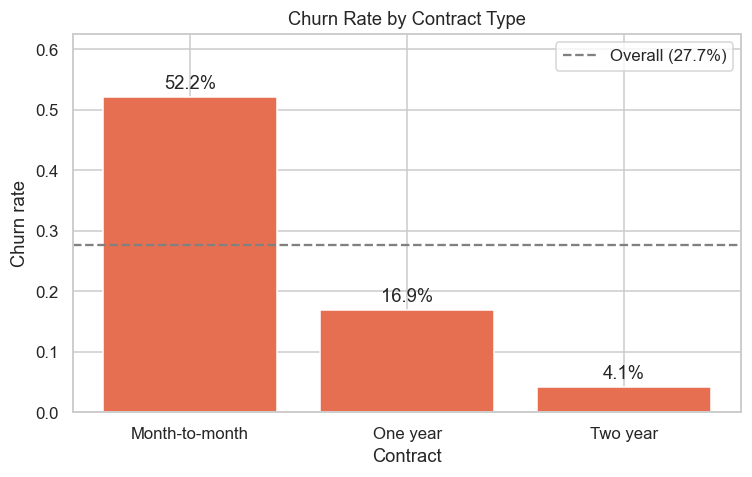

In [ ]:
# A numeric churn flag for averaging, without disturbing the readable labels
df_clean['Churn_flag'] = (df_clean['Churn'] == 'Yes').astype(int)

#Chart 1: Churn rate by contract type 
order = ['Month-to-month', 'One year', 'Two year']
rate_by_contract = df_clean.groupby('Contract')['Churn_flag'].mean().reindex(order)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(rate_by_contract.index, rate_by_contract.values, color="#E76F51")
ax.bar_label(bars, labels=[f'{v:.1%}' for v in rate_by_contract.values], padding=3)
ax.axhline(df_clean['Churn_flag'].mean(), ls='--', color='gray',
           label=f"Overall ({df_clean['Churn_flag'].mean():.1%})")
ax.set(title='Churn Rate by Contract Type', ylabel='Churn rate', xlabel='Contract')
ax.set_ylim(0, max(rate_by_contract.values) * 1.2)
ax.legend()
plt.tight_layout(); plt.savefig('fig1_churn_by_contract.png', bbox_inches='tight'); plt.show()


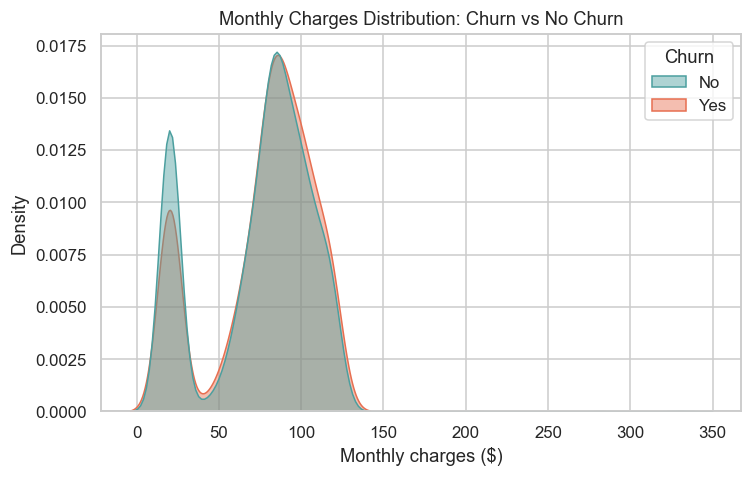

In [ ]:
#Chart 2: Monthly charges distribution, churners vs non-churners
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.kdeplot(data=df_clean, x='Monthly_Charges', hue='Churn',
            fill=True, common_norm=False, alpha=.45, palette=PALETTE, ax=ax)
ax.set(title='Monthly Charges Distribution: Churn vs No Churn',
       xlabel='Monthly charges ($)', ylabel='Density')
plt.tight_layout(); plt.savefig('fig2_monthly_charges.png', bbox_inches='tight'); plt.show()


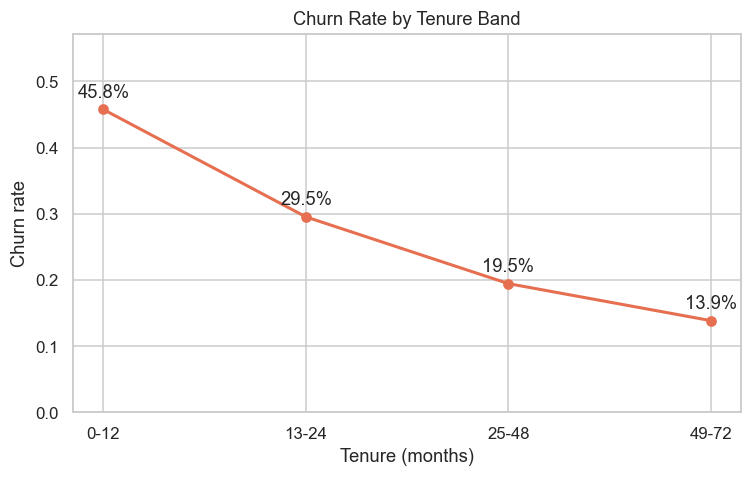

In [ ]:
#Chart 3: Churn rate by tenure band
bins   = [0, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49-72']
df_clean['Tenure_band'] = pd.cut(df_clean['Tenure_Months'], bins=bins,
                                 labels=labels, include_lowest=True)
rate_by_tenure = df_clean.groupby('Tenure_band', observed=True)['Churn_flag'].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(rate_by_tenure.index.astype(str), rate_by_tenure.values,
        marker='o', color="#E76F51", linewidth=2)
for x, y in zip(rate_by_tenure.index.astype(str), rate_by_tenure.values):
    ax.annotate(f'{y:.1%}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center')
ax.set(title='Churn Rate by Tenure Band', xlabel='Tenure (months)', ylabel='Churn rate')
ax.set_ylim(0, max(rate_by_tenure.values) * 1.25)
plt.tight_layout(); plt.savefig('fig3_churn_by_tenure.png', bbox_inches='tight'); plt.show()


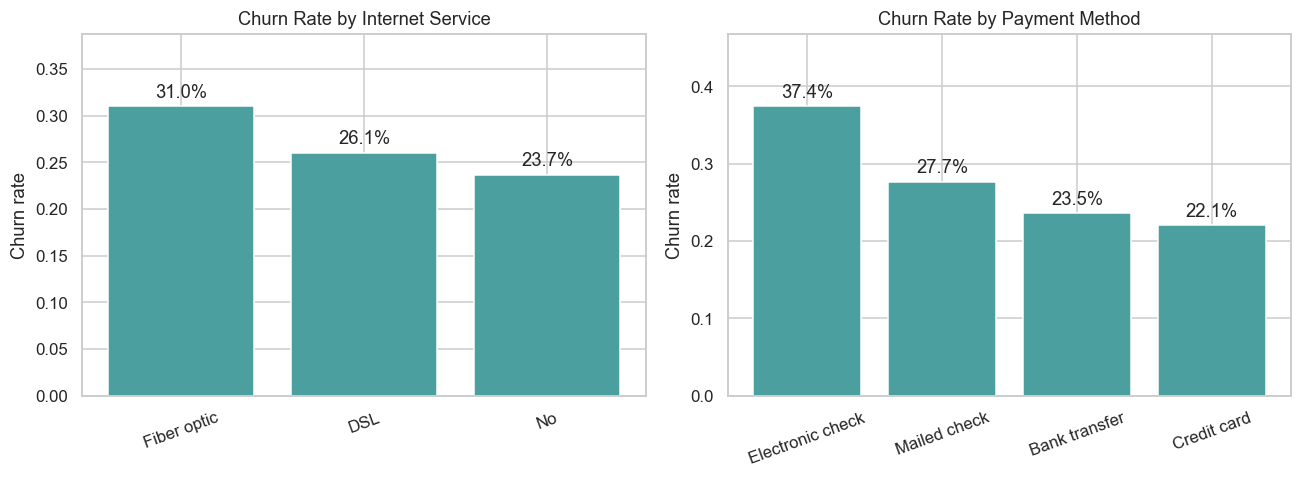

In [ ]:
#Chart 4 : churn rate by internet service & payment method
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ['Internet_Service', 'Payment_Method']):
    r = df_clean.groupby(col)['Churn_flag'].mean().sort_values(ascending=False)
    b = ax.bar(r.index, r.values, color="#4C9F9F")
    ax.bar_label(b, labels=[f'{v:.1%}' for v in r.values], padding=3)
    ax.set(title=f'Churn Rate by {col.replace("_", " ")}', ylabel='Churn rate')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, max(r.values) * 1.25)
plt.tight_layout(); plt.savefig('fig4_churn_by_service.png', bbox_inches='tight'); plt.show()


### 2.5 Encode categorical variables

**Encoding approach:**

- The six add-on columns plus `Multiple_Lines` carry a third value,
  *"No internet service"* / *"No phone service"*. Functionally the customer simply
  **does not have the feature**, so these collapse to **"No"** -> avoids redundant
  dummy columns that just re-encode `Internet_Service = No`.
- **Binary** Yes/No columns (and `Gender`) -> 0/1 mapping.
- **True multi-class** columns (`Internet_Service`, `Contract`, `Payment_Method`)
  -> one-hot encoding with `drop_first=True` to avoid the dummy-variable trap.
- `CustomerID` is dropped (identifier, not predictive).

In [ ]:
# Start encoding from the cleaned frame; drop EDA helper columns
df_enc = df_clean.drop(columns=['Churn_flag', 'Tenure_band']).copy()

# (a) collapse 'No internet/phone service' -> 'No'
service_cols = ['Online_Security', 'Online_Backup', 'Device_Protection',
                'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Multiple_Lines']
df_enc[service_cols] = df_enc[service_cols].replace(
    {'No internet service': 'No', 'No phone service': 'No'})

# (b) binary Yes/No -> 1/0  (plus Gender, plus the target)
binary_cols = ['Partner', 'Dependents', 'Phone_Service', 'Paperless_Billing'] + service_cols
for col in binary_cols:
    df_enc[col] = (df_enc[col] == 'Yes').astype(int)
df_enc['Gender'] = (df_enc['Gender'] == 'Male').astype(int)
df_enc['Churn']  = (df_enc['Churn']  == 'Yes').astype(int)

# (c) one-hot encode the true multi-class nominal columns
df_enc = pd.get_dummies(df_enc,
                        columns=['Internet_Service', 'Contract', 'Payment_Method'],
                        drop_first=True)

# (d) drop the identifier and convert any boolean dummies to int
df_enc = df_enc.drop(columns=['CustomerID'])
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print("Encoded feature matrix:", df_enc.shape)
df_enc.head()


Encoded feature matrix: (5000, 27)


,Gender,Age,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Online_Security,Online_Backup,...,Num_Support_Tickets,Avg_Monthly_Data_GB,Churn,Internet_Service_Fiber optic,Internet_Service_No,Contract_One year,Contract_Two year,Payment_Method_Credit card,Payment_Method_Electronic check,Payment_Method_Mailed check
0,1,53,0,1,1,10.0,1,0,0,0,...,11.0,156.1,0,0,0,1,0,0,0,0
1,1,40,0,0,0,71.0,1,1,0,0,...,1.0,261.6,0,1,0,0,0,0,1,0
2,0,44,0,1,0,52.0,1,1,1,1,...,7.0,284.0,0,1,0,1,0,0,0,0
3,0,56,0,0,0,62.0,1,0,0,0,...,5.0,42.3,0,0,0,1,0,0,0,1
4,0,28,0,0,0,22.0,1,0,0,0,...,3.0,0.0,1,0,1,0,1,1,0,0


### 2.6 Train/test split and feature scaling

We split **first**, then fit the `StandardScaler` on the **training data only** and
apply it to the test set, so no test information leaks into the scaler.

**Why scaling matters for neural networks:** an MLP learns through gradient descent.
If inputs live on very different scales (e.g. `Total_Charges` in the thousands vs a
0/1 flag), the large-magnitude features dominate the gradient, training is slow and
unstable, and the network can get stuck. Standardizing each feature to mean 0 /
std 1 puts them on equal footing so optimization converges reliably. (Distance- and
gradient-based models benefit; tree models would not.)

In [ ]:
# Features / target
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

# 80/20 stratified split keeps the ~28% churn rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Standardize the continuous numeric features (fit on TRAIN only)
numeric_feats = ['Age', 'Tenure_Months', 'Monthly_Charges', 'Total_Charges',
                 'Num_Support_Tickets', 'Avg_Monthly_Data_GB']
scaler = StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[numeric_feats] = scaler.fit_transform(X_train[numeric_feats])
X_test_s[numeric_feats]  = scaler.transform(X_test[numeric_feats])

print(f"Train: {X_train_s.shape},  churn rate {y_train.mean():.3f}")
print(f"Test : {X_test_s.shape},  churn rate {y_test.mean():.3f}")


Train: (4000, 26),  churn rate 0.277
Test : (1000, 26),  churn rate 0.277


## Step 3 - Algorithm Explanation & Model Results

The plain-English explanation of *what a neural network is* and *when it beats
simpler models* is in the report. Here we build and compare three models:

1. **Logistic Regression** - interpretable linear baseline.
2. **Neural Net (16)** - one hidden layer, 16 neurons (`MLPClassifier`).
3. **Neural Net (32, 16)** - two hidden layers, to test whether depth helps.

In [ ]:
# Define the three models. max_iter=1000 lets both networks fully converge.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Neural Net (16)'    : MLPClassifier(hidden_layer_sizes=(16,),
                                         max_iter=1000, random_state=RANDOM_STATE),
    'Neural Net (32,16)' : MLPClassifier(hidden_layer_sizes=(32, 16),
                                         max_iter=1000, random_state=RANDOM_STATE),
}

# Train each model and collect metrics (train + test, to expose overfitting)
records, preds, probas = [], {}, {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred_tr = model.predict(X_train_s)
    pred_te = model.predict(X_test_s)
    proba_te = model.predict_proba(X_test_s)[:, 1]
    preds[name], probas[name] = pred_te, proba_te
    records.append({
        'Model'      : name,
        'Train Acc'  : accuracy_score(y_train, pred_tr),
        'Test Acc'   : accuracy_score(y_test, pred_te),
        'Precision'  : precision_score(y_test, pred_te),
        'Recall'     : recall_score(y_test, pred_te),
        'F1'         : f1_score(y_test, pred_te),
        'ROC-AUC'    : roc_auc_score(y_test, proba_te),
    })
print("Training complete.")


Training complete.


### 3.1 Model comparison table

In [ ]:
# Side-by-side comparison (test-set metrics, plus train accuracy for overfit check)
comparison = pd.DataFrame(records).set_index('Model').round(4)
comparison


,Train Acc,Test Acc,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Logistic Regression,0.7798,0.767,0.5902,0.5199,0.5528,0.8048
Neural Net (16),0.8160,0.754,0.5660,0.4801,0.5195,0.7878
"Neural Net (32,16)",0.9258,0.741,0.5346,0.5018,0.5177,0.7525


### 3.2 Confusion matrices

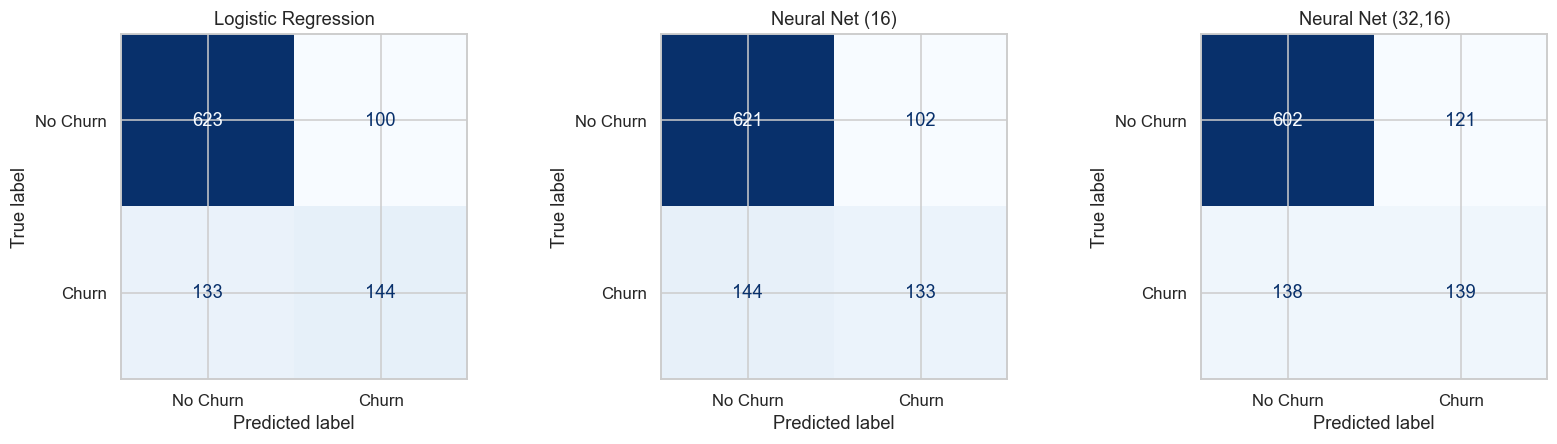

In [ ]:
# Confusion matrix for each model (rows = actual, cols = predicted)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig('fig5_confusion_matrices.png', bbox_inches='tight'); plt.show()


### 3.3 Detailed classification reports

In [ ]:
# Precision / recall / F1 per class for every model
for name, pred in preds.items():
    print('=' * 60)
    print(name)
    print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.82      0.86      0.84       723
       Churn       0.59      0.52      0.55       277

    accuracy                           0.77      1000
   macro avg       0.71      0.69      0.70      1000
weighted avg       0.76      0.77      0.76      1000

Neural Net (16)
              precision    recall  f1-score   support

    No Churn       0.81      0.86      0.83       723
       Churn       0.57      0.48      0.52       277

    accuracy                           0.75      1000
   macro avg       0.69      0.67      0.68      1000
weighted avg       0.74      0.75      0.75      1000

Neural Net (32,16)
              precision    recall  f1-score   support

    No Churn       0.81      0.83      0.82       723
       Churn       0.53      0.50      0.52       277

    accuracy                           0.74      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       

### 3.4 Overfitting check: training vs test accuracy

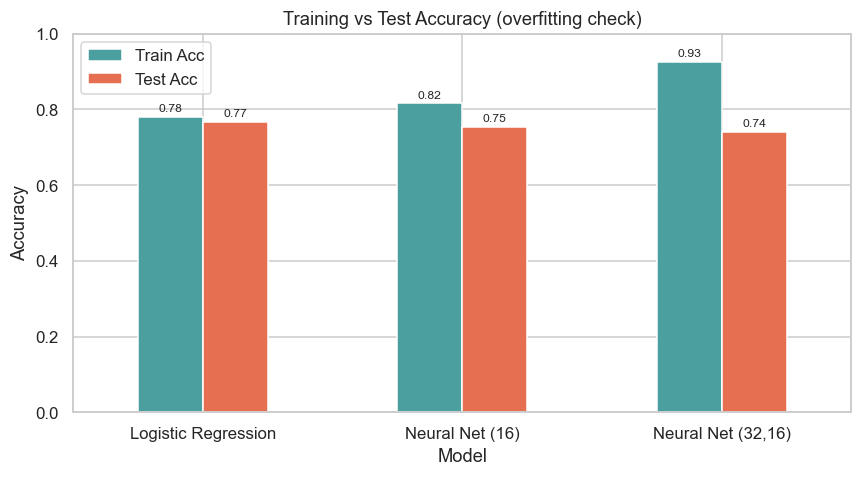

                     Train Acc  Test Acc     Gap
Model                                           
Logistic Regression     0.7798     0.767  0.0128
Neural Net (16)         0.8160     0.754  0.0620
Neural Net (32,16)      0.9258     0.741  0.1848


In [ ]:
# A large train-minus-test gap signals overfitting (memorizing, not generalizing)
gap = comparison[['Train Acc', 'Test Acc']].copy()
gap['Gap'] = (gap['Train Acc'] - gap['Test Acc']).round(4)

ax = gap[['Train Acc', 'Test Acc']].plot(kind='bar', figsize=(8, 4.5),
                                         color=['#4C9F9F', '#E76F51'], rot=0)
ax.set(title='Training vs Test Accuracy (overfitting check)', ylabel='Accuracy')
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', padding=2, fontsize=8)
plt.tight_layout(); plt.savefig('fig6_overfitting.png', bbox_inches='tight'); plt.show()
print(gap)


### 3.5 Test-set metric comparison

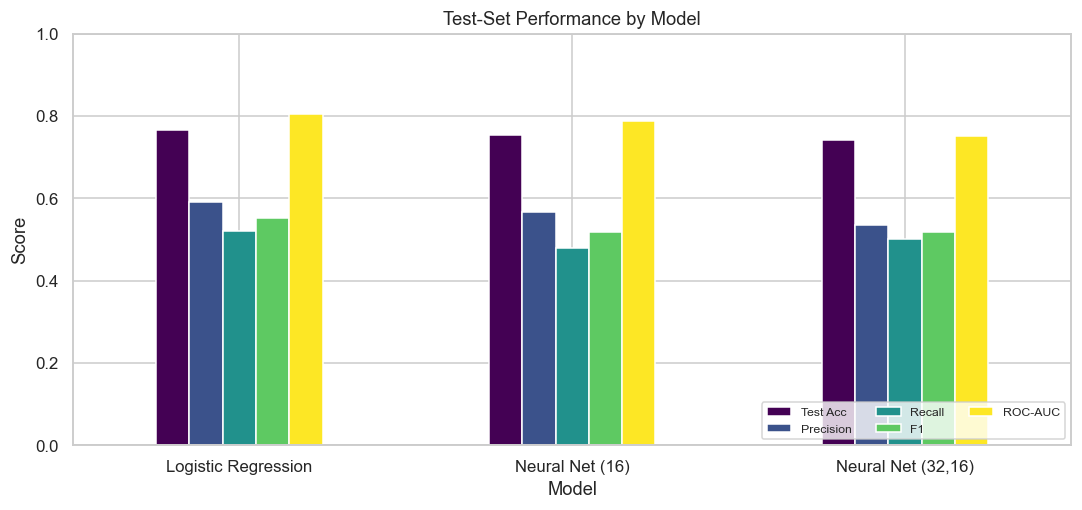

In [ ]:
# Visual comparison of the headline test-set metrics
metrics = ['Test Acc', 'Precision', 'Recall', 'F1', 'ROC-AUC']
ax = comparison[metrics].plot(kind='bar', figsize=(10, 4.8), rot=0,
                              colormap='viridis')
ax.set(title='Test-Set Performance by Model', ylabel='Score')
ax.set_ylim(0, 1); ax.legend(loc='lower right', ncol=3, fontsize=8)
plt.tight_layout(); plt.savefig('fig7_metric_comparison.png', bbox_inches='tight'); plt.show()


## Step 4 - Business Recommendations (supporting analysis)

The narrative recommendations are in the report. This section produces the
evidence behind them: the highest-risk customer segments, the drivers of churn,
and a concrete retention ROI.

### 4.1 Highest-risk customer segments

In [ ]:
# Churn rate by Contract x Internet service x Tech support (with segment size)
seg = (df_clean
       .groupby(['Contract', 'Internet_Service', 'Tech_Support'], observed=True)
       .agg(churn_rate=('Churn_flag', 'mean'),
            customers=('Churn_flag', 'size'))
       .reset_index())

# Focus on sizeable segments and rank by churn rate
top_segments = (seg[seg['customers'] >= 50]
                .sort_values('churn_rate', ascending=False)
                .head(8)
                .reset_index(drop=True))
top_segments['churn_rate'] = (top_segments['churn_rate'] * 100).round(1)
top_segments.rename(columns={'churn_rate': 'churn_rate_%'}, inplace=True)
print("Highest-risk segments (>= 50 customers):")
top_segments


Highest-risk segments (>= 50 customers):


,Contract,Internet_Service,Tech_Support,churn_rate_%,customers
0,Month-to-month,Fiber optic,No,64.1,557
1,Month-to-month,DSL,Yes,49.8,211
2,Month-to-month,DSL,No,48.4,479
3,Month-to-month,Fiber optic,Yes,47.2,358
4,Month-to-month,No,No internet service,46.5,432
5,One year,Fiber optic,No,23.4,411
6,One year,DSL,No,16.7,360
7,One year,Fiber optic,Yes,14.5,249


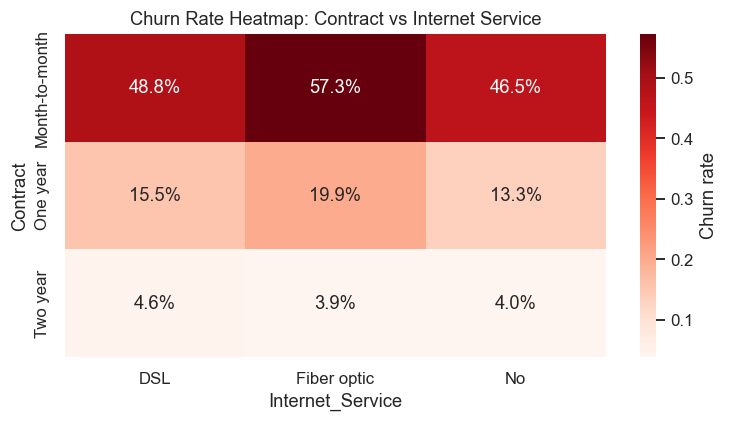

In [ ]:
# Heatmap: churn rate by Contract (rows) x Internet service (cols)
pivot = (df_clean.pivot_table(index='Contract', columns='Internet_Service',
                              values='Churn_flag', aggfunc='mean')
                 .reindex(['Month-to-month', 'One year', 'Two year']))
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='Reds', cbar_kws={'label': 'Churn rate'}, ax=ax)
ax.set(title='Churn Rate Heatmap: Contract vs Internet Service')
plt.tight_layout(); plt.savefig('fig8_segment_heatmap.png', bbox_inches='tight'); plt.show()


### 4.2 What drives churn (logistic-regression odds ratios)
Odds ratios from the interpretable baseline show the direction and strength of each
feature. A ratio > 1 raises churn odds; < 1 lowers them. This grounds the retention
offers in evidence.

In [ ]:
# Odds ratios = exp(coefficient) from the standardized logistic regression
lr = models['Logistic Regression']
odds = (pd.DataFrame({'feature': X_train_s.columns,
                      'odds_ratio': np.exp(lr.coef_[0])})
        .sort_values('odds_ratio', ascending=False))
print("Top 6 churn-increasing factors:")
print(odds.head(6).to_string(index=False))
print("\nTop 6 churn-reducing factors:")
print(odds.tail(6).to_string(index=False))


Top 6 churn-increasing factors:
                        feature  odds_ratio
   Internet_Service_Fiber optic    1.366211
            Num_Support_Tickets    1.218292
              Paperless_Billing    1.203703
               Streaming_Movies    1.101044
                 Senior_Citizen    1.080227
Payment_Method_Electronic check    1.049755

Top 6 churn-reducing factors:
            feature  odds_ratio
    Online_Security    0.789205
      Tenure_Months    0.715855
       Tech_Support    0.664371
Internet_Service_No    0.656582
  Contract_One year    0.216792
  Contract_Two year    0.054989


### 4.3 Retention ROI
Unit economics: a retention offer costs ~\$50; acquiring a replacement costs ~\$400.
The break-even targeting efficiency is `offer / acquire`. The table then projects
net savings for a campaign that targets every customer the model flags as churn,
across a range of offer-success rates.

In [ ]:
# --- Assumptions (edit freely) ---
offer_cost   = 50     # cost of a retention offer per targeted customer
acquire_cost = 400    # cost to acquire a replacement customer

breakeven = offer_cost / acquire_cost
print(f"Break-even: {breakeven:.1%} of targeted customers must be genuinely retained "
      f"for the campaign to pay for itself.\n")

# Use the best model by F1 to define who we would target on the test set
best_name = comparison['F1'].idxmax()
cm = confusion_matrix(y_test, preds[best_name])
tn, fp, fn, tp = cm.ravel()
flagged = tp + fp                      # everyone the model predicts will churn
print(f"Targeting model: {best_name}")
print(f"Customers flagged as churn (test set): {flagged}  "
      f"(of which {tp} truly churn -> precision {tp/flagged:.1%})\n")

# Net savings across plausible offer-success rates (fraction of true churners retained)
rows = []
for success in [0.20, 0.30, 0.40, 0.50]:
    saved      = tp * success
    campaign   = flagged * offer_cost
    avoided    = saved * acquire_cost
    rows.append({'offer_success_rate': f'{success:.0%}',
                 'customers_saved'   : round(saved, 1),
                 'campaign_cost_$'   : campaign,
                 'acq_cost_avoided_$': round(avoided),
                 'net_savings_$'     : round(avoided - campaign)})
roi = pd.DataFrame(rows)
roi


Break-even: 12.5% of targeted customers must be genuinely retained for the campaign to pay for itself.

Targeting model: Logistic Regression
Customers flagged as churn (test set): 244  (of which 144 truly churn -> precision 59.0%)



,offer_success_rate,customers_saved,campaign_cost_$,acq_cost_avoided_$,net_savings_$
0,20%,28.8,12200,11520,-680
1,30%,43.2,12200,17280,5080
2,40%,57.6,12200,23040,10840
3,50%,72.0,12200,28800,16600


### 4.4 Save artifacts
Persist the cleaned dataset and the model comparison so the report can cite them.

In [ ]:
comparison.to_csv('model_comparison.csv')
df_enc.to_csv('telco_churn_clean_encoded.csv', index=False)
print("Saved: model_comparison.csv, telco_churn_clean_encoded.csv, and figures fig1-fig8 .png")


Saved: model_comparison.csv, telco_churn_clean_encoded.csv, and figures fig1-fig8 .png
